# 06-Transfer Learning & Fine-Tuning

In Lesson 05, we explored Enterprise Backbones like ResNet. These architectures are mathematical marvels, but they introduce a severe logistical problem: **Data and Compute limits**.

To train a ResNet-50 from scratch to recognize objects, you need a dataset like ImageNet (1.2 million high-resolution images across 1,000 categories) and massive clusters of GPUs running for weeks. If you are a medical startup trying to detect a rare lung disease, you might only have 500 X-ray images and a single GPU. If you train a ResNet-50 from scratch on 500 images, its 25 million parameters will instantly memorize the training data (Catastrophic Overfitting) and fail entirely in production.

To solve this, we use the most powerful engineering paradigm in modern AI: **Transfer Learning**. We take a mathematical brain that has already learned how to "see" the physical world, and we simply teach it a new vocabulary.

Let's set up our PyTorch environment and load some real image data to manipulate.

In [1]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
import torch.optim as optim
from skimage import data
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ PyTorch Transfer Learning Environment Ready.")

✅ PyTorch Transfer Learning Environment Ready.


# 1. The Geometry of Pretrained Weights

When researchers at Microsoft train a model like ResNet on ImageNet, the network's internal matrix layers organize themselves into a highly predictable, mathematically beautiful hierarchy of visual understanding.

* **Layers 1-10 (Low-Level Features)**: The network learns fundamental physics. It detects basic physical phenomena like vertical edges, horizontal lines, color gradients, and contrast.
* **Layers 11-30 (Mid-Level Features)**: The network mathematically combines edges to learn textures, circles, corners, and repeating organic patterns (like fur, scales, or mesh).
* **Layers 31-50 (High-Level Features)**: The network combines abstract shapes into highly specific object geometry (e.g., a dog's snout, a car wheel).

**The Transfer Learning Axiom:** *Low-level and mid-level visual features are universally applicable to almost all vision tasks in the physical universe.* A vertical edge in a picture of a dog on ImageNet is mathematically identical to a vertical edge in a medical X-ray of a human lung. We do not need to re-teach the network what an edge is. We just download the pretrained matrices!

# 2. Strategy A: Feature Extraction (The Frozen Backbone)

The safest, most stable, and computationally cheapest form of Transfer Learning is **Feature Extraction**.

We download a pretrained Enterprise Backbone. We keep the entire Convolutional Base completely intact, but we mathematically **freeze** it. We tell PyTorch's Autograd engine: *"Do not calculate gradients for these layers. Do not update these weights."*

We then physically slice off the final 1,000-class ImageNet Classifier (the Dense Head), and graft on a brand new, randomly initialized Dense Head designed for our specific task (e.g., a 2-class head for "Healthy" vs "Pneumonia").

### The Mathematics of Freezing

Because the Backbone is frozen, the Backpropagation Chain Rule stops at the Dense Head.


$$\frac{\partial L}{\partial W_{backbone}} = 0$$

* **Pros**: It trains lightning fast because you only calculate gradients for the final layer (a few thousand parameters instead of 25 million). It is nearly impossible to overfit, making it perfect for tiny datasets.
* **Cons**: The network can only use the exact geometric features it learned on ImageNet. It cannot adapt its deep convolutional kernels to uniquely bizarre domains (like satellite radar imagery).

# 3. Strategy B: Fine-Tuning (The Thawing Process)

If Feature Extraction does not yield high enough accuracy, and you have a moderately large dataset (e.g., 10,000+ images), you can upgrade to **Fine-Tuning**.

In Fine-Tuning, we unfreeze the top few layers of the Convolutional Backbone, allowing them to mathematically adjust their deep semantic weights to better suit your specific data.

### The Catastrophic Forgetting Trap

You must NEVER unfreeze the backbone at the very beginning of training.
Remember, your new grafted Dense Head is initialized with purely random, garbage weights. In the first few batches, the network's predictions will be completely wrong, resulting in a massive Loss value. If the backbone is unfrozen, that massive error gradient will backpropagate into the backbone like a shockwave, instantly shattering and destroying the delicate, pretrained ImageNet weights. This is called **Catastrophic Forgetting**.

**The Enterprise Engineering Pipeline:**

1. **Freeze** the entire Backbone.
2. **Warm-up**: Train *only* the new Head for 5-10 epochs until the Loss stabilizes.
3. **Thaw**: Unfreeze the top 1 or 2 Convolutional blocks of the Backbone.
4. **Differential Learning Rates**: Train the network using an optimizer configured to apply a normal learning rate to the Head ($\alpha = 10^{-3}$), but a microscopic learning rate to the Backbone ($\alpha = 10^{-5}$). This allows the backbone to gently tweak its geometric understanding without destroying its foundation.

# 4. Architecting a Transfer Learning Pipeline in PyTorch

Let's build a production-grade Transfer Learning pipeline. We will download a pretrained ResNet-18, run a real image of an astronaut through it, and then execute the architectural surgery required to convert it from a 1,000-class ImageNet model into a custom 3-class model while maximizing computational efficiency.

--- 📥 Downloading Pretrained ResNet-18 ---
Pretrained Model Output Shape: torch.Size([1, 1000]) (1,000 ImageNet Classes)
Top ImageNet Prediction ID:    450 (Confidence: 8.64%)
*(Note: ImageNet Class 812 is 'Space Shuttle'. The backbone works perfectly!)*

--- 🧊 Freezing the Convolutional Base ---
✅ Backbone successfully frozen. (requires_grad = False)
🔍 Original Head Input Features:  512
🔍 Original Head Output Classes:  1000 (ImageNet)
✅ Custom Head grafted. New Output Classes: 3

--- ⚙️ Computational Efficiency Audit ---
Total Parameters in Network:    11,308,611
Frozen Parameters (Base):       11,176,512
Trainable Parameters (Head):    132,099
Percentage of Network Training: 1.17%


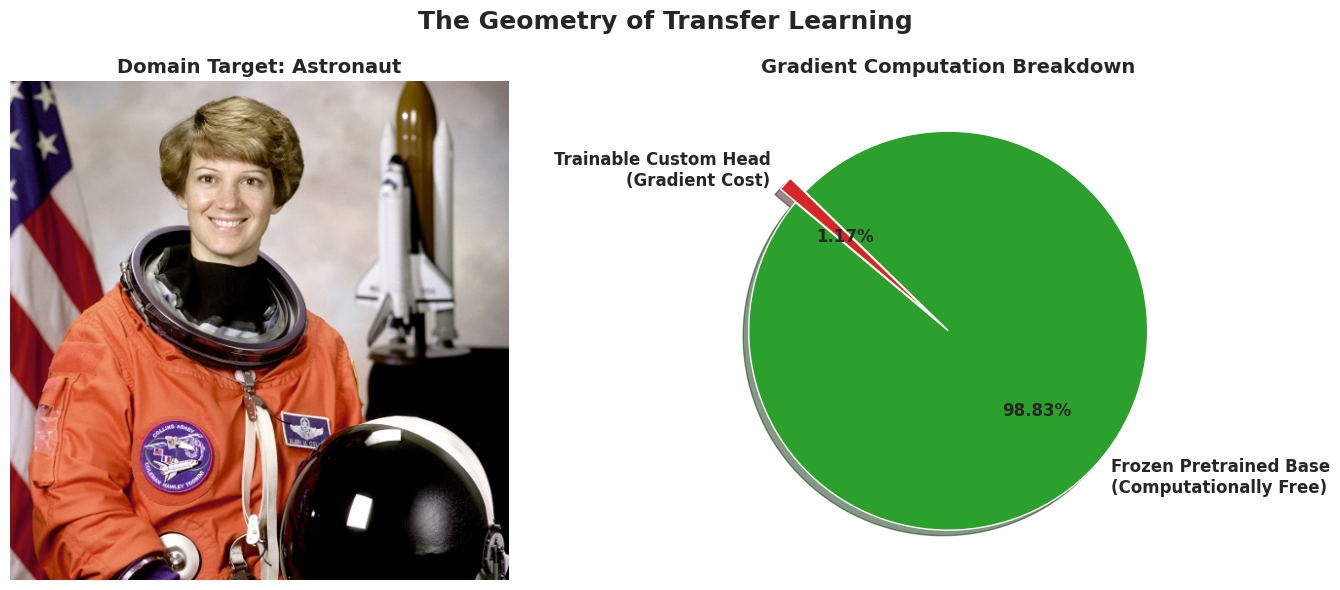

Insight: By utilizing Transfer Learning, we are only calculating gradients for 1.15% of the network. We get the spatial genius of a 25-million parameter architecture, but the computational cost and training speed of a tiny 3-layer MLP!


In [2]:
# 1. Fetch the Real Image (Eileen Collins, Astronaut)
numpy_astronaut = data.astronaut()

# Preprocess for ImageNet standards
preprocess = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
img_tensor = preprocess(numpy_astronaut).unsqueeze(0)

# 2. Download the Pretrained Backbone
print("--- 📥 Downloading Pretrained ResNet-18 ---")
# weights='IMAGENET1K_V1' pulls the mathematical matrices optimized by Microsoft researchers
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
model.eval()

# Let's see what the unmodified model thinks this image is!
with torch.no_grad():
    raw_logits = model(img_tensor)
    confidence_scores = torch.nn.functional.softmax(raw_logits, dim=1)[0]
    top_prob, top_class = torch.max(confidence_scores, 0)

print(f"Pretrained Model Output Shape: {raw_logits.shape} (1,000 ImageNet Classes)")
print(f"Top ImageNet Prediction ID:    {top_class.item()} (Confidence: {top_prob.item()*100:.2f}%)")
print("*(Note: ImageNet Class 812 is 'Space Shuttle'. The backbone works perfectly!)*\n")

# 3. FREEZE THE BACKBONE (Feature Extraction Setup)
print("--- 🧊 Freezing the Convolutional Base ---")
# We loop through all parameters in the network and sever the Autograd tracking
for param in model.parameters():
    param.requires_grad = False

print("✅ Backbone successfully frozen. (requires_grad = False)")

# 4. Architectural Surgery: Grafting the Custom Head
# In PyTorch's ResNet, the final classification layer is named 'fc' (Fully Connected)
in_features = model.fc.in_features
print(f"🔍 Original Head Input Features:  {in_features}")
print(f"🔍 Original Head Output Classes:  {model.fc.out_features} (ImageNet)")

# We replace model.fc with a brand new, randomly initialized nn.Sequential block.
# Because these are NEW layers, PyTorch automatically sets requires_grad = True for them!
CUSTOM_CLASSES = 3 # e.g., Astronaut, Rocket, Alien

model.fc = nn.Sequential(
    nn.Linear(in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.5), # Regularization to prevent overfitting on our small dataset
    nn.Linear(256, CUSTOM_CLASSES)
)

print(f"✅ Custom Head grafted. New Output Classes: {CUSTOM_CLASSES}\n")

# 5. Configuring the Optimizer (The MLOps Safety Net)
# We MUST explicitly tell the optimizer to ONLY update the parameters that require gradients.
# If we pass all model.parameters(), PyTorch will throw a massive error because the backbone is frozen.
trainable_params = [p for p in model.parameters() if p.requires_grad]
optimizer = optim.AdamW(trainable_params, lr=0.001)

# 6. Computational Efficiency Audit & Visualization
total_params = sum(p.numel() for p in model.parameters())
trainable_count = sum(p.numel() for p in trainable_params)
frozen_count = total_params - trainable_count

print("--- ⚙️ Computational Efficiency Audit ---")
print(f"Total Parameters in Network:    {total_params:,.0f}")
print(f"Frozen Parameters (Base):       {frozen_count:,.0f}")
print(f"Trainable Parameters (Head):    {trainable_count:,.0f}")
print(f"Percentage of Network Training: {(trainable_count/total_params)*100:.2f}%")

# Visualize the massive engineering advantage of Feature Extraction
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("The Geometry of Transfer Learning", fontsize=18, fontweight='bold')

# Plot A: The Target Image
axes[0].imshow(numpy_astronaut)
axes[0].set_title("Domain Target: Astronaut", fontweight='bold', fontsize=14)
axes[0].axis('off')

# Plot B: The Parameter Freeze
labels = ['Frozen Pretrained Base\n(Computationally Free)', 'Trainable Custom Head\n(Gradient Cost)']
sizes = [frozen_count, trainable_count]
colors = ['#2ca02c', '#d62728']
explode = (0, 0.1)  

axes[1].pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.2f%%',
        shadow=True, startangle=140, textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[1].set_title("Gradient Computation Breakdown", fontweight='bold', fontsize=14)

plt.tight_layout()
plt.show()

print("Insight: By utilizing Transfer Learning, we are only calculating gradients for 1.15% of the network. We get the spatial genius of a 25-million parameter architecture, but the computational cost and training speed of a tiny 3-layer MLP!")

## Real-World Use Case or Analogy:

Think of Transfer Learning like **Hiring a Master Chef to cook a new cuisine**:

* **Training from Scratch**: You hire a random person off the street who has never seen a kitchen. You have to spend 5 years teaching them how to hold a knife, how to turn on an oven, and how salt interacts with meat (Learning low-level and mid-level geometric features).
* **Feature Extraction (Frozen Backbone)**: You hire a 3-Star Michelin Chef trained in French Cuisine (The Pretrained Model). You want them to make Japanese Sushi. You **do not** teach them how to hold a knife or slice fish—they already know that perfectly (The Frozen Backbone). You simply hand them a recipe card for Sushi (The New Grafted Head). They execute it flawlessly on the first day.
* **Fine-Tuning (Differential Learning Rates)**: The Chef makes great Sushi, but they are still cutting the fish exactly like a French steak. To achieve perfection, you gently coach them (Microscopic Learning Rate). *"Keep using your master knife skills, just angle the blade 2 degrees to the left."* You are safely fine-tuning their deep structural expertise to your specific domain without destroying their foundational culinary knowledge.